# EDA — MDS Bone Marrow Cell Dataset

**Nguồn**: figshare, DOI `10.6084/m9.figshare.28737170.v1` — "A large dataset of bone marrow cells in myelodysplastic syndrome for classification systems" (Scientific Data, 2025).

**Nội dung**: `Data/images/mds_bone_marrow/extracted/` — 25.067 ảnh JPEG, 54 thư mục lớp con (33 loại tế bào × `main/`+`add/`), gán nhãn bởi tối đa 3 chuyên gia.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
ROOT = Path(r'D:\AI_08_V1\Data\images\mds_bone_marrow\extracted')
IMG_EXT = {'.jpg', '.jpeg', '.png'}

class_counts = {}
for sub in sorted(ROOT.rglob('*')):
    if sub.is_dir():
        n = sum(1 for f in sub.iterdir() if f.is_file() and f.suffix.lower() in IMG_EXT)
        if n > 0:
            class_counts[str(sub.relative_to(ROOT))] = n

counts = pd.Series(class_counts).sort_values(ascending=False)
print('Tổng số ảnh:', counts.sum())
print('Tổng số lớp:', len(counts))
print(f'Tỷ lệ mất cân bằng (max/min): {counts.max()/counts.min():.0f} lần')
counts.head(10)

Tổng số ảnh: 25009
Tổng số lớp: 54
Tỷ lệ mất cân bằng (max/min): 3958 lần


main\Mature lymphocyte             3958
main\Late erythroblast             3555
main\Smudge cell                   2215
main\Band neutrophil               2208
main\Intermediate erythroblast     2084
main\Segmented neutrophil          1743
main\Neutrophilic metamyelocyte    1291
main\Myeloblast                    1045
add\Smudge cell                     912
main\Neutrophilic myelocyte         828
dtype: int64

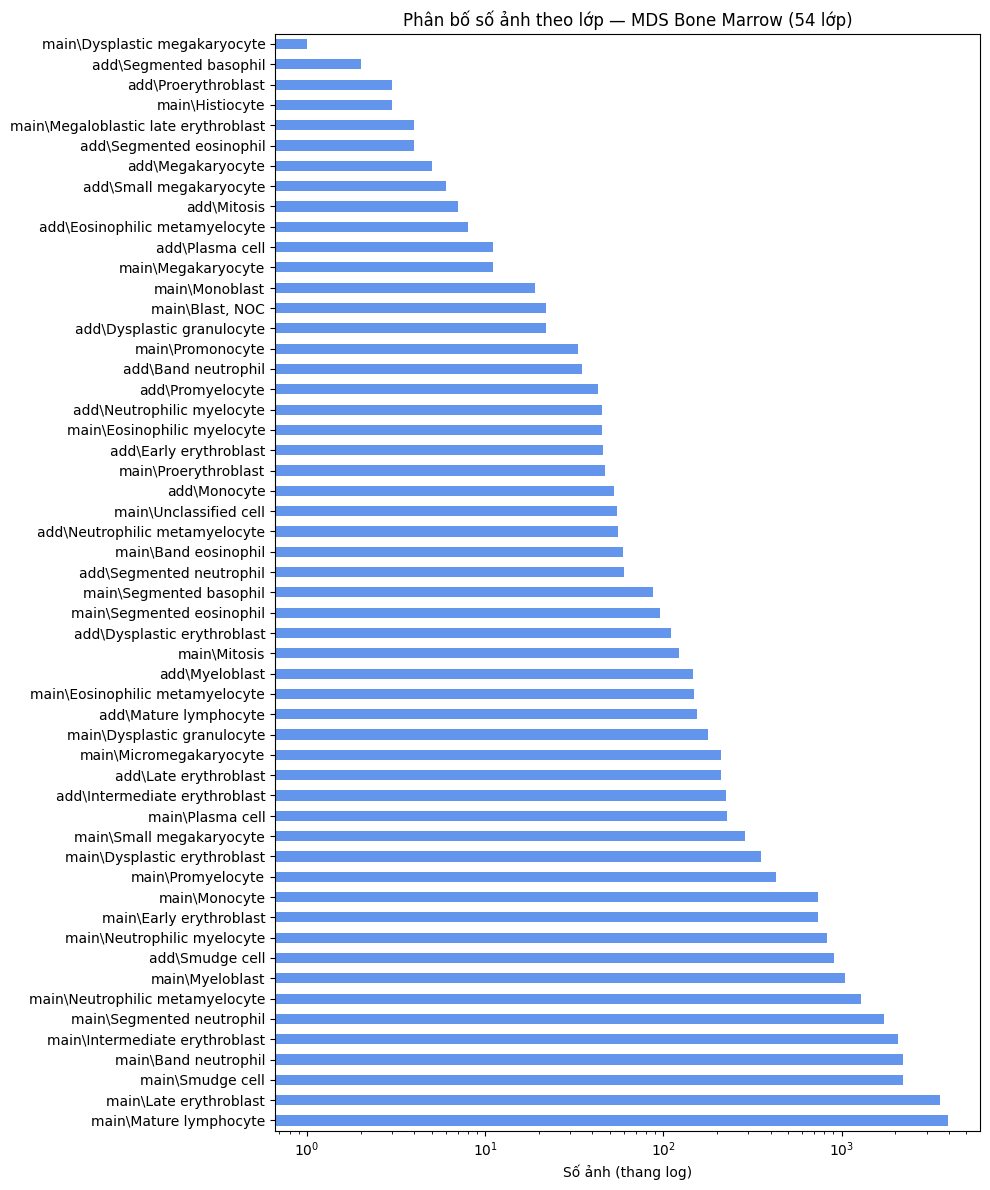

Các lớp có dưới 10 ảnh (không đủ để train riêng):
add\Eosinophilic metamyelocyte          8
add\Mitosis                             7
add\Small megakaryocyte                 6
add\Megakaryocyte                       5
add\Segmented eosinophil                4
main\Megaloblastic late erythroblast    4
main\Histiocyte                         3
add\Proerythroblast                     3
add\Segmented basophil                  2
main\Dysplastic megakaryocyte           1
dtype: int64


In [2]:
# Biểu đồ phân bố số ảnh theo lớp (toàn bộ 54 lớp) — thang log để thấy rõ mất cân bằng
fig, ax = plt.subplots(figsize=(10, 12))
counts.plot.barh(ax=ax, logx=True, color='cornflowerblue')
ax.set_xlabel('Số ảnh (thang log)')
ax.set_title('Phân bố số ảnh theo lớp — MDS Bone Marrow (54 lớp)')
plt.tight_layout()
plt.show()

print('Các lớp có dưới 10 ảnh (không đủ để train riêng):')
print(counts[counts < 10])

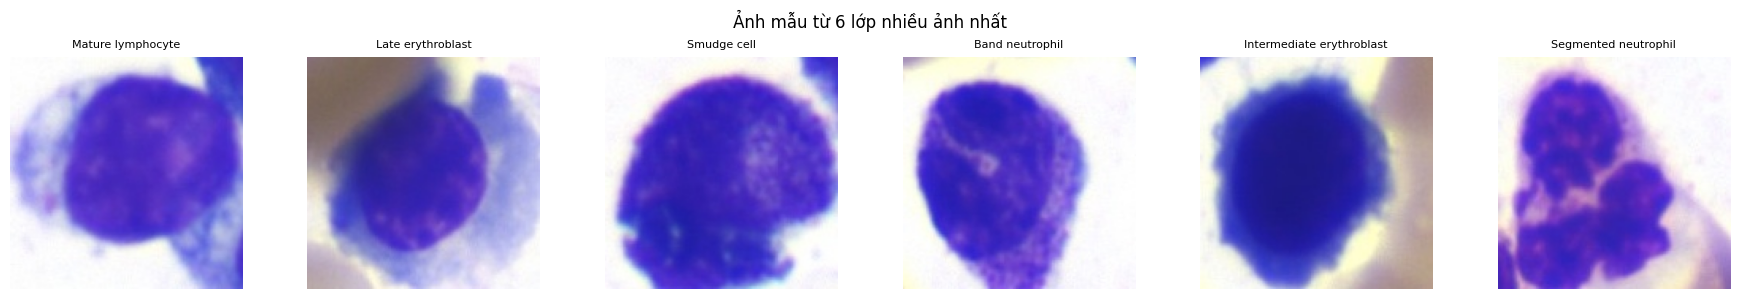

In [3]:
# Xem thử vài ảnh mẫu từ 6 lớp phổ biến nhất
from PIL import Image

top6 = counts.head(6).index.tolist()
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, cls in zip(axes, top6):
    sample_file = next((ROOT / cls).glob('*.jp*g'))
    img = Image.open(sample_file)
    ax.imshow(img)
    ax.set_title(cls.split('\\')[-1], fontsize=8)
    ax.axis('off')
plt.suptitle('Ảnh mẫu từ 6 lớp nhiều ảnh nhất')
plt.tight_layout()
plt.show()

## Nhận xét

- **Mất cân bằng cực đoan**: lớp nhiều nhất `Mature lymphocyte` = 3.958 ảnh, lớp ít nhất `Dysplastic megakaryocyte` = chỉ 1 ảnh — lệch ~3.958 lần.
- Nhiều lớp dưới 10 ảnh — không đủ để train riêng, bắt buộc gộp nhóm hoặc dùng few-shot/augmentation mạnh.
- Đây là nguồn ảnh **duy nhất** trong kho có gán nhãn tế bào bất thường thật sự liên quan bệnh lý huyết học (MDS), độ tin cậy nhãn cao (tối đa 3 chuyên gia).